In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage

In [3]:
# =========================
# 1. LLM Setup
# =========================
llm = init_chat_model(model="mistral-medium")

In [4]:
# =========================
# 2. State Definition
# =========================
class ChatState(TypedDict):
    query: str
    category: str
    response: str

In [5]:
# =========================
# 3. Agents
# =========================

# 🔹 Classifier Agent
def classifier_agent(state: ChatState):
    query = state["query"]

    prompt = f"""
    Classify the user query into one of:
    - Billing
    - Technical
    - General

    Query: {query}
    Only return the category name.
    """

    category = llm.invoke(prompt).content.strip()

    return {"category": category}


# 🔹 Billing Agent
def billing_agent(state: ChatState):
    query = state["query"]

    prompt = f"""
    You are a Billing Support Agent.
    Resolve the query clearly.

    Query: {query}
    """

    response = llm.invoke(prompt).content
    return {"response": response}


# 🔹 Technical Agent
def technical_agent(state: ChatState):
    query = state["query"]

    prompt = f"""
    You are a Technical Support Agent.
    Help fix the issue step by step.

    Query: {query}
    """

    response = llm.invoke(prompt).content
    return {"response": response}


# 🔹 General Agent
def general_agent(state: ChatState):
    query = state["query"]

    prompt = f"""
    You are a Customer Support Assistant.
    Answer general questions clearly.

    Query: {query}
    """

    response = llm.invoke(prompt).content
    return {"response": response}


# 🔹 Response Agent (Final Formatter)
def response_agent(state: ChatState):
    final_output = f"""
    ✅ Category: {state['category']}

    💬 Response:
    {state['response']}
    """

    return {"response": final_output}

In [6]:
# =========================
# 4. Routing Logic
# =========================
def route_query(state: ChatState):
    category = state["category"].lower()

    if "billing" in category:
        return "billing"
    elif "technical" in category:
        return "technical"
    else:
        return "general"

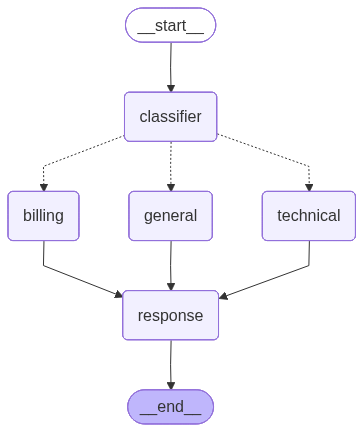

In [ ]:
# =========================
# 5. Build Graph
# =========================
graph = StateGraph(ChatState)

# Nodes
graph.add_node("classifier", classifier_agent)
graph.add_node("billing", billing_agent)
graph.add_node("technical", technical_agent)
graph.add_node("general", general_agent)
graph.add_node("response", response_agent)

# Flow
graph.add_edge(START, "classifier")

graph.add_conditional_edges(
    "classifier",
    route_query,
    {
        "billing": "billing",
        "technical": "technical",
        "general": "general",
    }
)

graph.add_edge("billing", "response")
graph.add_edge("technical", "response")
graph.add_edge("general", "response")

graph.add_edge("response", END)

# Compile
workflow = graph.compile()
workflow

In [8]:
# =========================
# 6. Run Test Cases
# =========================
def run_query(user_input):
    result = workflow.invoke({
        "query": user_input,
        "category": "",
        "response": ""
    })
    return result["response"]

In [10]:
# =========================
# 7. Example Runs
# =========================
queries = [
    "I was charged twice for my subscription",
    # "The app crashes when I open it",
    # "What are your pricing plans?"
]

for q in queries:
    print("USER:", q)
    print(run_query(q))
    print("="*50)

USER: I was charged twice for my subscription

    ✅ Category: Billing

    💬 Response:
    **Subject:** Resolution for Duplicate Subscription Charge

Dear [Customer's Name],

Thank you for reaching out regarding the duplicate charge for your subscription. I sincerely apologize for any inconvenience this may have caused. Here’s how we’ll resolve this:

### **Steps Taken:**
1. **Verification:** I’ve reviewed your account and confirmed a duplicate charge for [Subscription Name] on [Date(s)] for [Amount].
2. **Refund Initiated:** The duplicate charge of **[Amount]** has been **refunded** to your original payment method (e.g., credit card, bank account). Please allow **3–5 business days** for the refund to reflect, depending on your bank’s processing time.
3. **Prevention:** We’ve flagged your account to prevent future duplicate charges.

### **Next Steps:**
- **Check Your Bank Statement:** The refund should appear within the timeframe mentioned above.
- **Confirmation Email:** You’ll rece